# #Radiology Throughput Analysis: CT vs MRI 🏥

## ##Overview
This project analyzes radiology throughput by comparing CT and MRI scan wait times and procedure volumes across different quarters of the year. The goal is to identify whether there are seasonal trends that may affect patient wait times, imaging demand, workflow efficiency, and patient care.

## ##Research Question
How do patients' wait times and procedure volumes for CT scans compare to MRI scans across different quarters of the year, and are there identifiable seasonal trends in radiology throughput?

## ##Data Sources
- CMS Hospital Outpatient Quality Reporting Program: https://www.cms.gov/medicare/quality/initiatives/hospital-quality-initiative/hospital-outpatient-quality-reporting-program
- CMS Provider Data Catalog — Outpatient Imaging Efficiency: https://data.cms.gov/provider-data/dataset/wkfw-kthe
- CMS Hospitals — Timely & Effective Care: https://data.cms.gov/provider-data/topics/hospitals/timely-effective-care
- Kaggle Healthcare Datasets: https://www.kaggle.com/datasets

## ##Files Included
- `radiology_throughput.ipynb`: Jupyter Notebook containing the Python analysis, charts, and written interpretation
- `radiology_data.csv`: Cleaned dataset used for the project
- Visualizations:
  - Bar chart comparing average CT and MRI wait times by quarter
  - Bar chart comparing CT and MRI procedure volumes by quarter
  - Optional line chart showing seasonal trends over time

## Tools Used
- Python
- pandas
- matplotlib
- seaborn
- Google Colab / Jupyter Notebook

## Instructions
1. Open the notebook in Google Colab or Jupyter Notebook.
2. Run the first code cell to import the required Python libraries.
3. Create or upload the `radiology_data.csv` dataset.
4. Run each cell in order to clean the data, group it by quarter and modality, and generate the charts.
5. Review the Results & Interpretation and Conclusion sections.

## Author
Brittany Applewhite

## Citations
- Centers for Medicare & Medicaid Services. Hospital Outpatient Quality Reporting Program. https://www.cms.gov/medicare/quality/initiatives/hospital-quality-initiative/hospital-outpatient-quality-reporting-program  
- Centers for Medicare & Medicaid Services. Outpatient Imaging Efficiency — Hospital. https://data.cms.gov/provider-data/dataset/wkfw-kthe  
- Centers for Medicare & Medicaid Services. Hospitals: Timely & Effective Care. https://data.cms.gov/provider-data/topics/hospitals/timely-effective-care  
- Kaggle. Healthcare datasets. https://www.kaggle.com/datasets  
- ChatGPT (OpenAI). Assistance with data cleaning, Python scripting, visualization planning, and project organization was provided using ChatGPT. Accessed May 2026.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
import pandas as pd
import numpy as np

# Create sample data
np.random.seed(42)

dates = pd.date_range(start="2023-01-01", end="2023-12-31", freq='W')

data = []

for date in dates:
    for modality in ['CT', 'MRI']:
        wait_time = np.random.randint(20, 60) if modality == 'CT' else np.random.randint(30, 90)
        volume = np.random.randint(30, 80) if modality == 'CT' else np.random.randint(20, 60)

        data.append([date, modality, wait_time, volume])

df = pd.DataFrame(data, columns=['Date', 'Modality', 'Wait_Time', 'Volume'])

df.head()

,Date,Modality,Wait_Time,Volume
0,2023-01-01,CT,58,58
1,2023-01-01,MRI,44,27
2,2023-01-08,CT,40,68
3,2023-01-08,MRI,87,38
4,2023-01-15,CT,42,40


In [ ]:
df.to_csv("radiology_data.csv", index=False)

In [ ]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Create Quarter column
df['Quarter'] = df['Date'].dt.to_period('Q')

df.head()

,Date,Modality,Wait_Time,Volume,Quarter
0,2023-01-01,CT,58,58,2023Q1
1,2023-01-01,MRI,44,27,2023Q1
2,2023-01-08,CT,40,68,2023Q1
3,2023-01-08,MRI,87,38,2023Q1
4,2023-01-15,CT,42,40,2023Q1


In [ ]:
grouped = df.groupby(['Quarter', 'Modality']).agg({
    'Wait_Time': 'mean',
    'Volume': 'sum'
}).reset_index()

grouped

,Quarter,Modality,Wait_Time,Volume
0,2023Q1,CT,47.384615,653
1,2023Q1,MRI,61.846154,476
2,2023Q2,CT,33.307692,704
3,2023Q2,MRI,48.615385,565
4,2023Q3,CT,41.076923,730
5,2023Q3,MRI,57.153846,482
6,2023Q4,CT,42.071429,719
7,2023Q4,MRI,64.071429,491


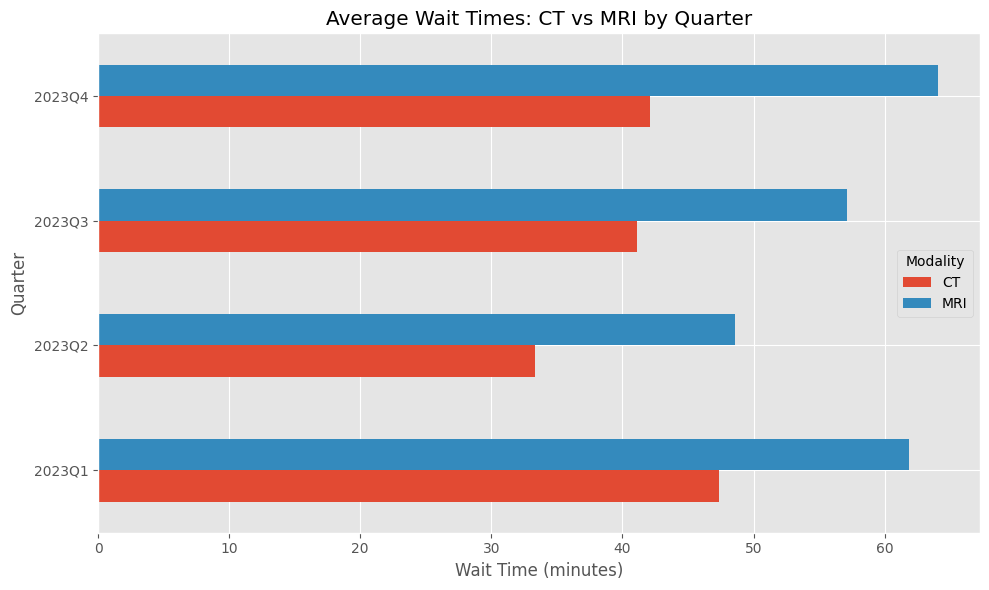

In [ ]:
pivot_wait = grouped.pivot(index='Quarter', columns='Modality', values='Wait_Time')

pivot_wait.plot(kind='barh', figsize=(10,6))

plt.title("Average Wait Times: CT vs MRI by Quarter")
plt.xlabel("Wait Time (minutes)")
plt.ylabel("Quarter")

plt.tight_layout()
plt.show()

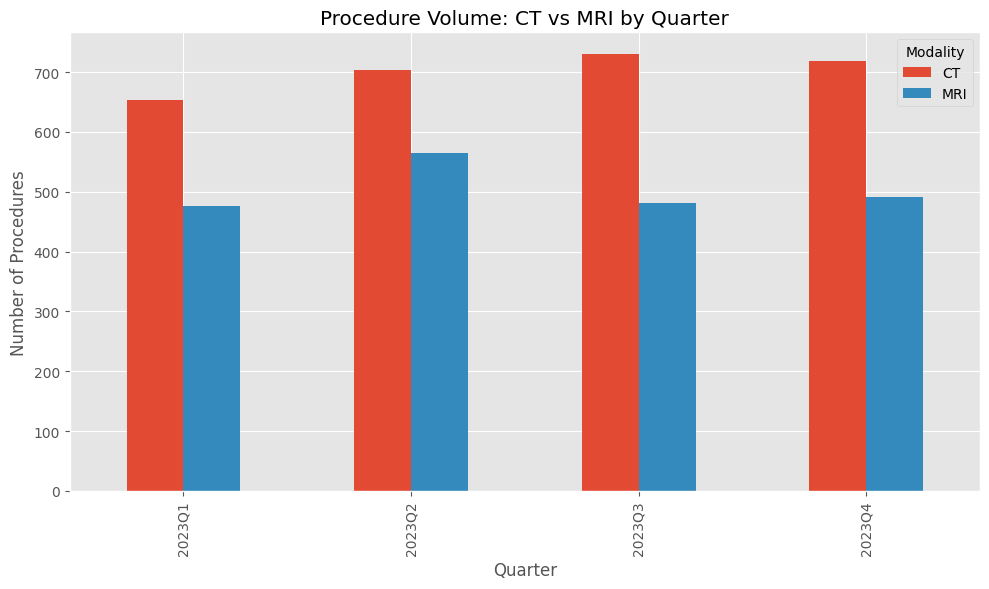

In [ ]:
pivot_vol = grouped.pivot(index='Quarter', columns='Modality', values='Volume')

pivot_vol.plot(kind='bar', figsize=(10,6))

plt.title("Procedure Volume: CT vs MRI by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Number of Procedures")

plt.tight_layout()
plt.show()

## ##Results & Interpretation
The analysis compares CT and MRI performance across quarters based on wait times and procedure volumes.

From the wait time chart, CT scans consistently show higher average wait times than MRI across all quarters. This suggests that CT services may be experiencing higher demand or operational bottlenecks.

MRI wait times appear lower overall, though there is some variability between quarters, indicating potential seasonal or operational fluctuations.

From the procedure volume chart, CT scans have significantly higher procedure volumes than MRI in every quarter. This aligns with the longer wait times observed for CT, as higher demand typically leads to increased delays.

Both CT and MRI show slight variations across quarters, suggesting possible seasonal trends. For example, procedure volumes appear to increase mid-year and stabilize toward the end of the year.

Overall, CT services experience higher demand and longer wait times, while MRI services are less utilized but more efficient in terms of patient wait times.

## ##Conclusion
This project analyzed radiology throughput by comparing CT and MRI scan performance across different quarters.

The findings indicate that CT scans consistently handle a higher volume of procedures, which contributes to longer patient wait times. In contrast, MRI scans maintain lower wait times but serve fewer patients overall.

Seasonal trends were observed, with moderate fluctuations in both wait times and procedure volumes across quarters. These variations may be influenced by patient demand, staffing levels, or operational scheduling.

These insights can help healthcare administrators improve resource allocation, reduce wait times, and optimize radiology department efficiency.